#### Seminar #4. Exploratory data analysis

Goals/Agenda
- Exploratory data analysis for band gap and Li-ion conductivity datasets

- Data visualization

- Finding trends and correlations



In [10]:
!pip install pymatgen

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.size'] = 10

### Band gap dataset

In [3]:
# download files
!mkdir data
!wget -O./data/mp_eg_data.csv https://raw.githubusercontent.com/dembart/intro-to-materials-informatics/refs/heads/main/data/seminar04/mp_eg_data.csv

--2026-10-05 11:48:57--  https://raw.githubusercontent.com/dembart/intro-to-materials-informatics/refs/heads/main/data/seminar04/mp_eg_data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2798844 (2.7M) [text/plain]
Saving to: ‘./data/mp_eg_data.csv’

./data/mp_eg_data.c 100%[===================>]   2.67M  12.4MB/s    in 0.2s    

2026-10-05 11:48:58 (12.4 MB/s) - ‘./data/mp_eg_data.csv’ saved [2798844/2798844]



In [4]:
data = pd.read_csv('data/mp_eg_data.csv')

In [5]:
# statistics for numerical columns
data.describe()

,eg,nelements
count,103217.000000,103217.000000
mean,0.790016,3.294370
std,1.365640,0.888434
min,0.000000,1.000000
25%,0.000000,3.000000
50%,0.000000,3.000000
75%,1.144800,4.000000
max,17.891400,8.000000


In [6]:
# what about median?
data.median(numeric_only = True)

,0
eg,0.0
nelements,3.0


We see that the median value for the band gap distribution is 0.0 eV. It means at least a half of the population are metals.

In [7]:
print('number of metals', (data.eg == 0).sum())
print('number of non-metals', (data.eg > 0).sum())

number of metals 59505
number of non-metals 43712


There are two large groups. By plotting the histogram we see that there is a huge peak at x = 0.0 corresponding to the metals group. So, it's better to analyse each group separately.

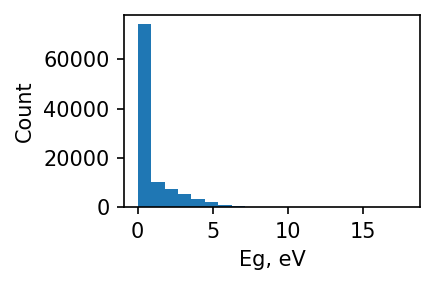

In [11]:
fig, ax = plt.subplots(dpi = 150, figsize = (3, 2))
_ = ax.hist(data.eg, bins = 20)

ax.set_xlabel('Eg, eV')
ax.set_ylabel('Count')
#ax.set_yscale('log')
plt.tight_layout()



In [12]:
metals = data[data.eg == 0.0]
nonmetals = data[data.eg > 0.0]

In [13]:
nonmetals.describe()

,eg,nelements
count,43712.000000,43712.000000
mean,1.865462,3.623696
std,1.548406,0.837801
min,0.000100,1.000000
25%,0.606900,3.000000
50%,1.500700,4.000000
75%,2.798300,4.000000
max,17.891400,8.000000


In [14]:
nonmetals.aggregate(
                {
                "eg": ["min", "max", "median", "skew", "std"]
                }
)

,eg
min,0.000100
max,17.891400
median,1.500700
skew,1.084769
std,1.548406


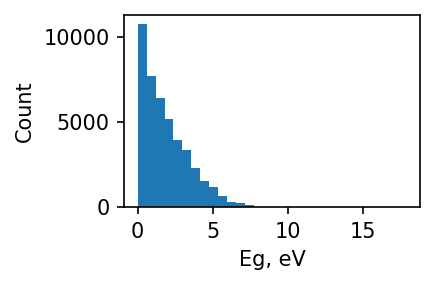

In [15]:
fig, ax = plt.subplots(dpi = 150, figsize = (3, 2))
_ = ax.hist(nonmetals.eg, bins = 30)

ax.set_xlabel('Eg, eV')
ax.set_ylabel('Count')
#ax.set_yscale('log')
plt.tight_layout()

Although the distribution is still very asymmetric, the descriptive statistics for the non-metal group (mean, median) is significantly different from the original dataset.

Let's check if oxygen containing structures has 0 band gap

In [16]:
def has_oxygen(chemsys):
    if 'O' in chemsys.split('-'):
        return True
    else:
        return False

In [17]:
metals['has_oxygen'] = metals['chemsys'].apply(has_oxygen).values

/tmp/ipykernel_1516/2255053184.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metals['has_oxygen'] = metals['chemsys'].apply(has_oxygen).values


In [18]:
metals[metals.has_oxygen == True]

,eg,chemsys,nelements,formula,has_oxygen
128,0.0,Ac-Cu-F-O,4,AcCuO2F,True
129,0.0,Ac-Cu-O,3,AcCuO3,True
167,0.0,Ac-Mg-O,3,AcMgO3,True
170,0.0,Ac-Mn-O,3,AcMnO3,True
176,0.0,Ac-Ni-O,3,AcNiO3,True
...,...,...,...,...,...
103138,0.0,Cu-H-O-S-Zn,5,Zn3Cu2H14(SO9)2,True
103141,0.0,Cu-O-P-Zn,4,Zn3CuP2O9,True
103142,0.0,Co-Fe-O-Zn,4,Zn3Fe12(CoO12)2,True
103143,0.0,Fe-O-Zn,3,Zn3Fe2O7,True


As you can see, there are a lot of oxygen-containing structures with a zero gap. Is that OK? No, we know that oxygen-containing materials in general have a non-metallic behavior. The reason for this observation is that the given dataset is calculated using the PBE exchange-correlation functional, which underestimates a band gap. In reality, most of these systems are non-metallic.

That's it for metals. It's more interesting to try to find the correlations between the band gap value and the chemical composition of non-metals.

In [19]:
nonmetals.drop(columns = ['chemsys']).groupby('formula').mean() # there are 27403 unique chemical compositions

,eg,nelements
formula,,
Ac2Br2O,0.2006,3.0
Ac2Cl2O,0.2363,3.0
Ac2MgGa,0.2016,3.0
Ac2MgTl,0.2200,3.0
Ac2O3,3.5226,2.0
...,...,...
ZrTlCuSe3,0.2271,4.0
ZrTlF5,4.8808,3.0
ZrVF6,2.4073,3.0


In [20]:
nonmetals.drop(columns = ['formula']).groupby('chemsys').mean() # there are 17387 unique chemical compositions

,eg,nelements
chemsys,,
Ac-Ag-Te,0.079400,3.0
Ac-Al-O,4.102400,3.0
Ac-B-O,0.807100,3.0
Ac-Br,4.103300,2.0
Ac-Br-O,2.220800,3.0
...,...,...
Te-Tl-Y,0.726600,3.0
Te-W,0.869140,2.0
Te-Zn,0.771620,2.0


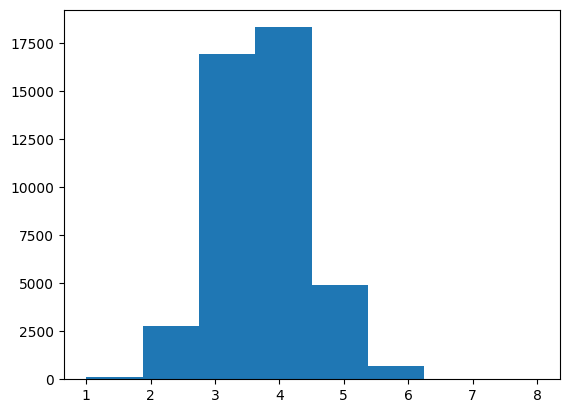

In [21]:
# distribution of the number of chemical elements in a structure
_ = plt.hist(nonmetals.nelements, bins = max(nonmetals.nelements), ec = 'k')

Let's create more data

In [22]:
from pymatgen.core import Composition

def _electrons_per_atom(formula):
    comp = Composition(formula)
    return comp.total_electrons / comp.num_atoms



def _average_electroneg(formula):
    try:
        comp = Composition(formula)

        return comp.average_electroneg
    except:
        return None



def _contains_halogen(formula):
    comp = Composition(formula)
    return comp.contains_element_type('halogen')

In [23]:
nonmetals['elneg_mean'] = nonmetals['formula'].apply(_average_electroneg)
nonmetals = nonmetals.dropna()
nonmetals['has_halogen'] = nonmetals['formula'].apply(_contains_halogen)
nonmetals['electrons_per_atom'] = nonmetals['formula'].apply(_electrons_per_atom)

# below are warnings that pymatgen is not able to
# append electronegativity for Ar, He, and Ne, and instead set it to Nan.
# It would be great to remove this elements from the dataset.
# This can be called dataset cleansing

/usr/lib/python3.13/functools.py:1025: UserWarning: No Pauling electronegativity for Ar. Setting to NaN. This has no physical meaning, and is mainly done to avoid errors caused by the code expecting a float.
  val = self.func(instance)
/usr/lib/python3.13/functools.py:1025: UserWarning: No Pauling electronegativity for He. Setting to NaN. This has no physical meaning, and is mainly done to avoid errors caused by the code expecting a float.
  val = self.func(instance)
/usr/lib/python3.13/functools.py:1025: UserWarning: No Pauling electronegativity for Ne. Setting to NaN. This has no physical meaning, and is mainly done to avoid errors caused by the code expecting a float.
  val = self.func(instance)
/tmp/ipykernel_1516/1208727159.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.htm

In [24]:
nonmetals.drop(columns = ['chemsys', 'formula']).groupby('has_halogen').mean()

,eg,nelements,elneg_mean,electrons_per_atom
has_halogen,,,,
False,1.698330,3.648030,2.532132,18.607942
True,2.399461,3.546685,2.820922,19.405383


In [25]:
nonmetals.drop(columns = ['chemsys', 'formula']).groupby('has_halogen').std()

,eg,nelements,elneg_mean,electrons_per_atom
has_halogen,,,,
False,1.399708,0.845607,0.332317,10.101855
True,1.824771,0.804404,0.382382,10.664142


In average, structures that contain halogen element have a wider bandgap

Let's check if $E_g$ correlates with number of electrons per atom and the average electronegativity

-0.1844108993409915
0.17162431885029783


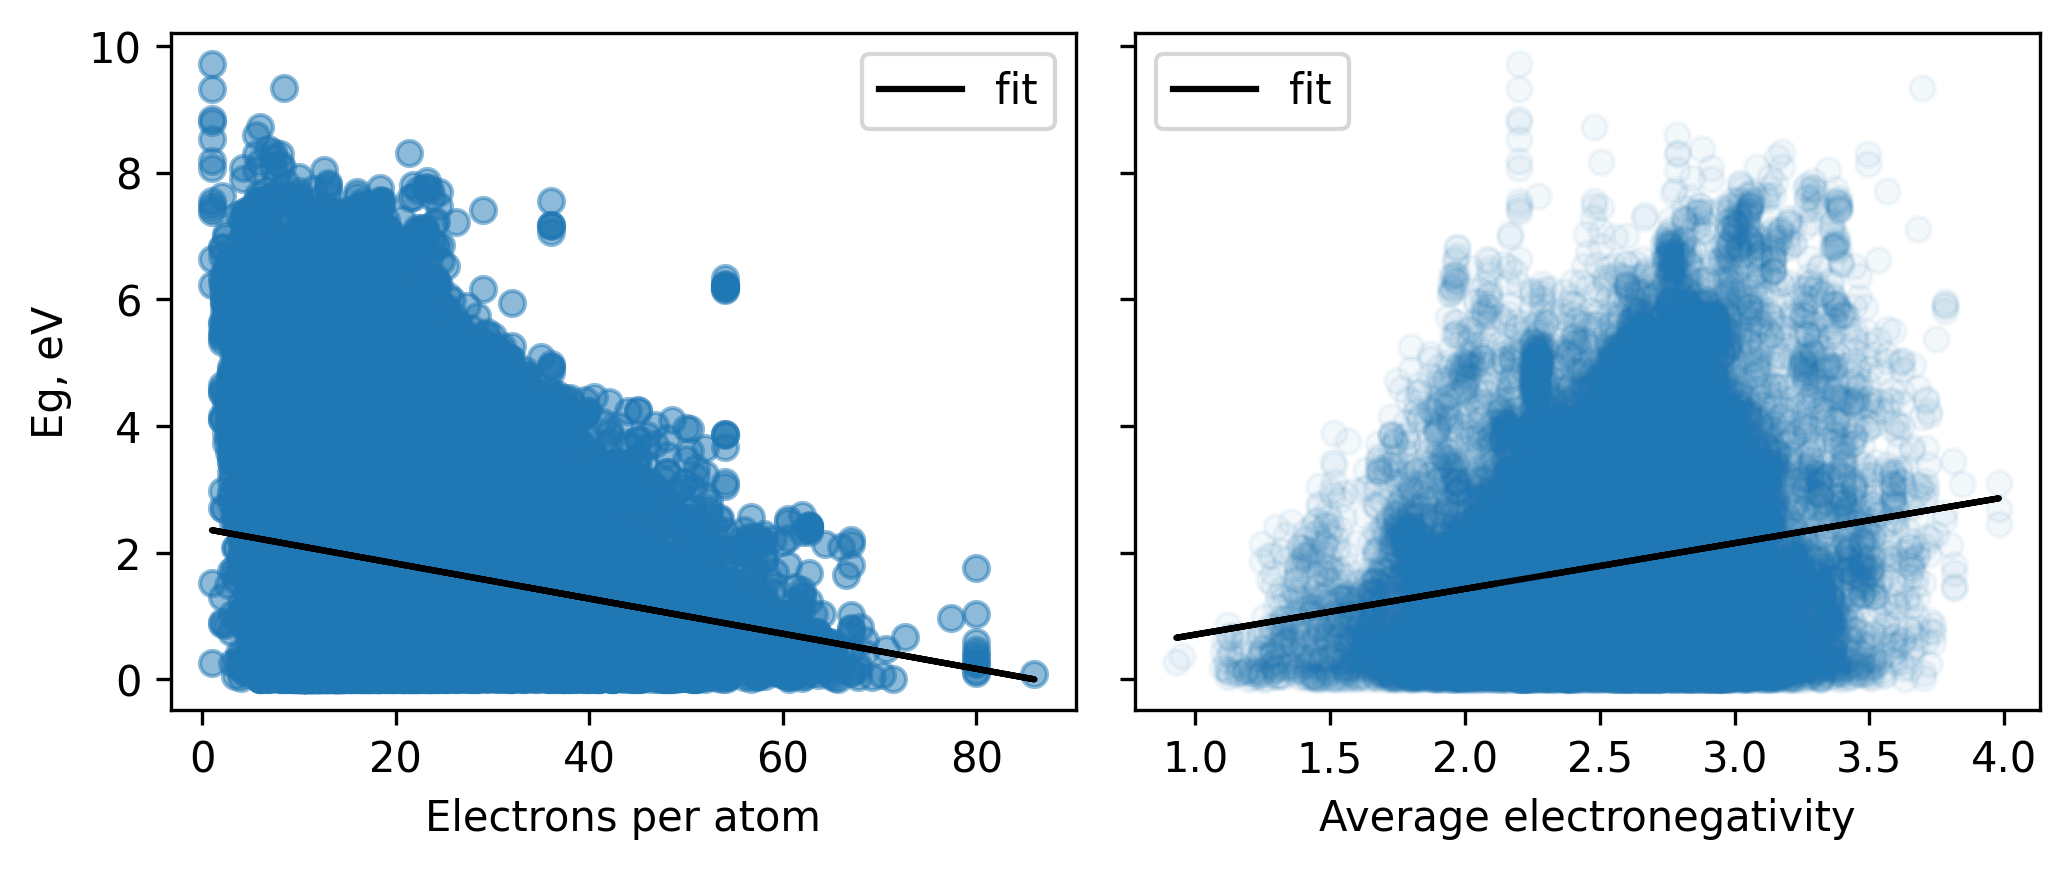

In [26]:
from scipy.stats import linregress

fig, (ax1, ax2) = plt.subplots(dpi = 300, ncols = 2, figsize = (7, 3), sharey = True)

x = nonmetals.electrons_per_atom
y = nonmetals.eg

ax1.scatter(x, y, alpha = 0.5)
ax1.set_xlabel('Electrons per atom')
ax1.set_ylabel('Eg, eV')
res = linregress(x, y)
print(res.rvalue)

ax1.plot(x, res.slope * x + res.intercept, color = 'k', label = 'fit')



x = nonmetals.elneg_mean


ax2.scatter(x, nonmetals.eg, alpha = 0.05)
res = linregress(nonmetals.elneg_mean,nonmetals.eg)
print(res.rvalue)
ax2.plot(x, res.slope * x + res.intercept, color = 'k', label = 'fit')
ax2.set_xlabel('Average electronegativity')
ax1.legend()
ax2.legend()

plt.tight_layout()

The correlation is weak.

However, there are many chemical compositions (i.e. too many groups). Let's assign a chemical family to each chemical system so that we have a smaller number of groups to work with.

In [27]:
def get_family(chemsys):

    """
    not the best one aggregation
    you can play with it
    """
    elements = chemsys.split('-')


    if 'O' in elements:
        if ('S' in elements)&('P' not in elements):
            return 'sulfate'
        elif ('P' in elements)&('S' not in elements):
            return 'phosphate'
        elif ('Si' in elements)&('P' not in elements):
            return 'silicate'
        else:
            return 'oxide'



    if 'F' in elements:
        return 'fluoride'

    if 'S' in elements:
        return 'sulfide'

    if 'P' in elements:
        return 'phosphide'

    if 'Cl' in elements:
        return 'chloride'

    if 'I' in elements:
        return 'iodide'

    if 'Br' in elements:
        return 'bromide'

    else:
        return 'other'

In [28]:
nonmetals['family'] = nonmetals['chemsys'].apply(get_family)

Let's count number of samples in each family

In [29]:
nonmetals.groupby('family').count()

,eg,chemsys,nelements,formula,elneg_mean,has_halogen,electrons_per_atom
family,,,,,,,
bromide,565,565,565,565,565,565,565
chloride,1221,1221,1221,1221,1221,1221,1221
fluoride,3189,3189,3189,3189,3189,3189,3189
iodide,436,436,436,436,436,436,436
other,4183,4183,4183,4183,4183,4183,4183
oxide,24932,24932,24932,24932,24932,24932,24932
phosphate,3795,3795,3795,3795,3795,3795,3795
phosphide,366,366,366,366,366,366,366
silicate,1678,1678,1678,1678,1678,1678,1678


In [30]:
groups = nonmetals.drop(columns = ['chemsys', 'formula']).groupby('family').mean().reset_index()
groups['eg_std'] = nonmetals.drop(columns = ['chemsys', 'formula']).groupby('family').std().reset_index()['eg']
groups = groups.sort_values(by = 'eg')
x = groups.family
y = groups.eg
#y_err = groups.eg_std


Text(0.5, 0, 'Eg, eV')

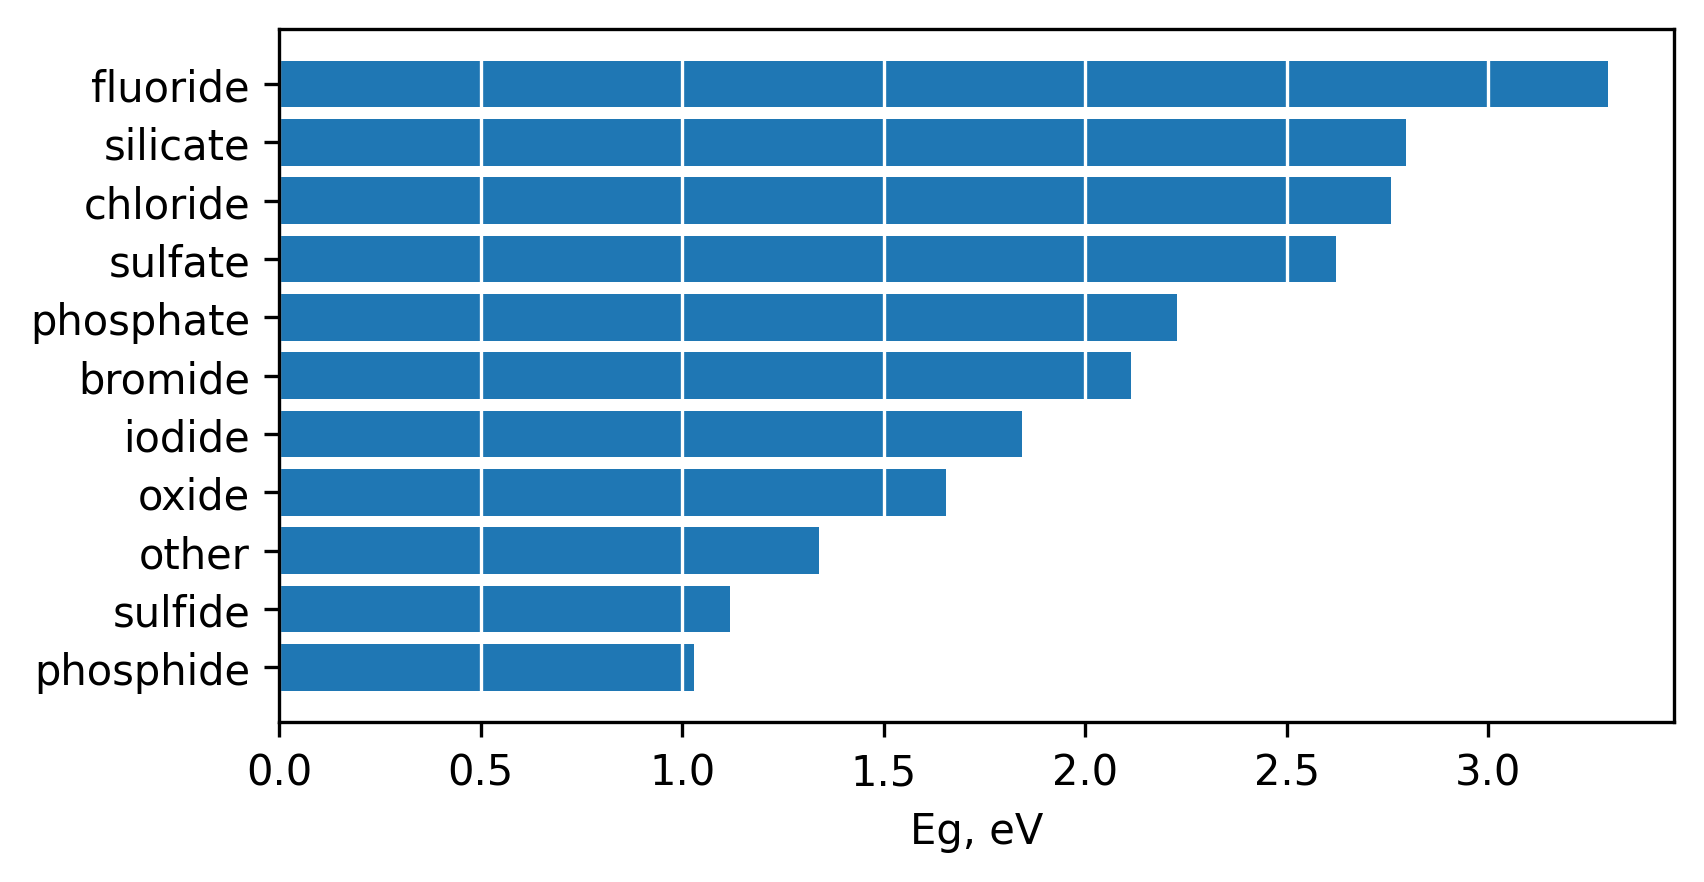

In [31]:
fig, ax = plt.subplots(dpi = 300, figsize = (6, 3))
ax.barh(x, y)
ax.xaxis.grid(True, color = 'w')
ax.set_xlabel('Eg, eV')


In average, fluoride materials have a wider band gap, while phoshides have the lowest band gap among the groups.

/tmp/ipykernel_1516/802728239.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax.boxplot(


Text(0, 0.5, 'Eg, eV')

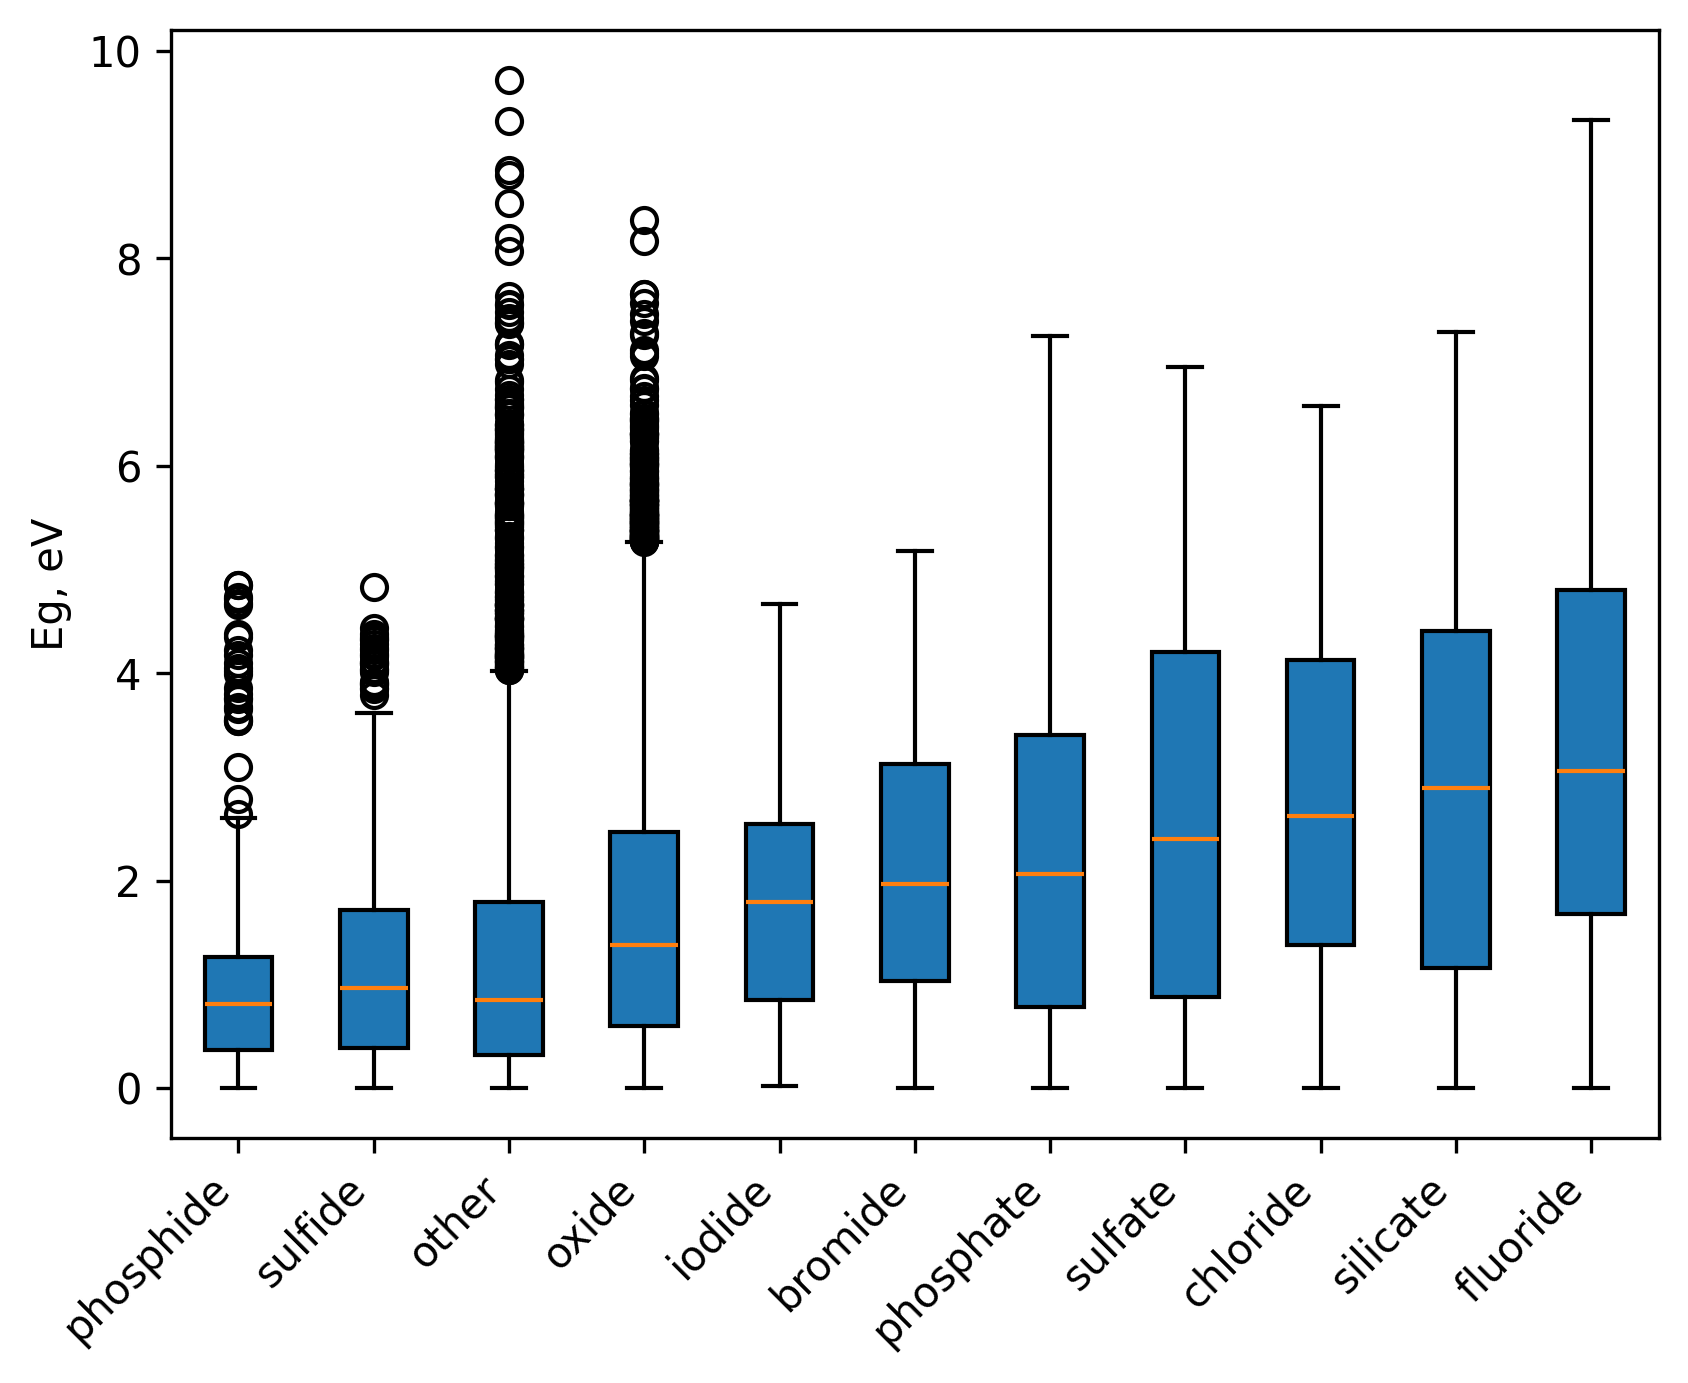

In [32]:
fig, ax = plt.subplots(dpi = 300)

families = groups.family
bplot = ax.boxplot(
[nonmetals[nonmetals.family == family].eg for family in families
],
                   patch_artist=True,  # fill with color

                   labels = families
                   )  # will

_ = ax.set_xticks(ax.get_xticks(), ax.get_xticklabels(), rotation=45, ha='right')

ax.set_ylabel('Eg, eV')
#fig.savefig('figures/eg_family_barplot.png')



However, the deviation of the band gap in each of the groups from the mean value of each of the groups is high.

Now, let's plot $<$mean elneg$>$ vs. $<E_g>$ for each group.

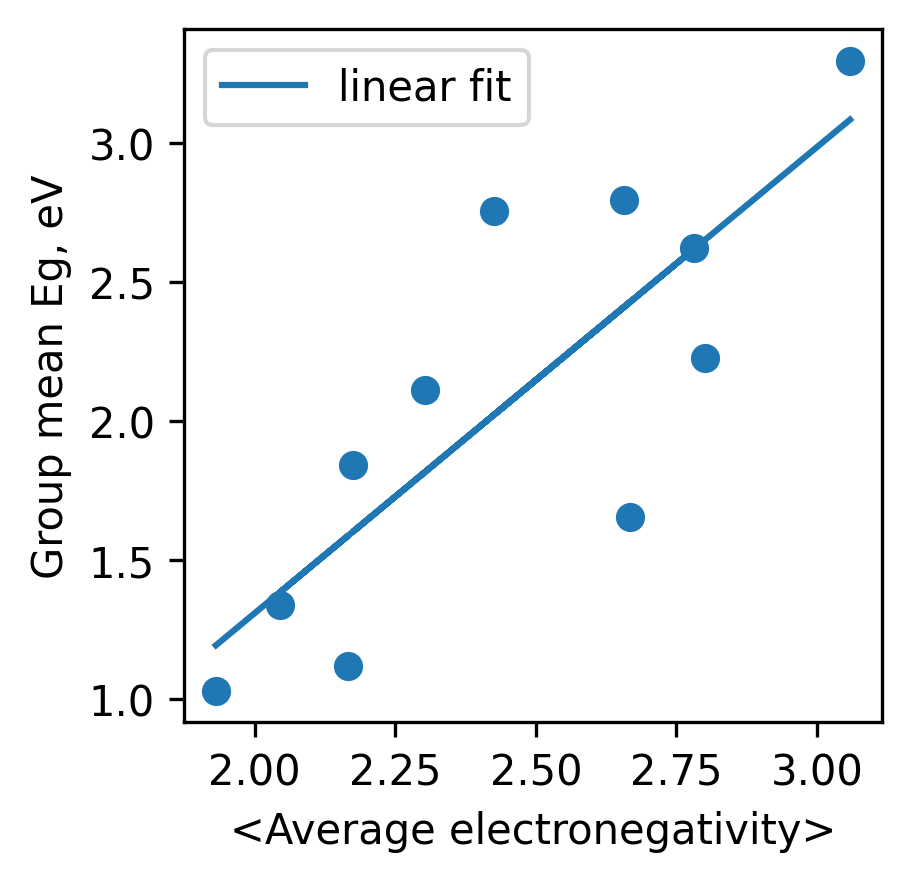

In [62]:
fig, ax = plt.subplots(dpi = 300, figsize  = (3, 3))

x = groups.elneg_mean
y = groups.eg
ax.scatter(x, y)
res = linregress(x, y)
res

ax.plot(x, res.slope * x + res.intercept, label = 'linear fit')
ax.set_xlabel('<Average electronegativity>')
ax.set_ylabel('Group mean Eg, eV')
ax.legend()


In [63]:
# Pearson correlation coefficient
print('Rp:', res.rvalue.round(2))

Rp: 0.81


Now we see that there is a strong correlation between the average Eg of a group and the average electronegativity.

#### Task 1

Study the correlation between the bandgap and average electronegativity in binary nonmetallic compounds (nelements == 2). Consider only halides and oxides for this study (i.e., binary systems containing O, Cl, Br, F, and I).
- plot Eg distribution for binary compounds
- plot Eg vs. Average electronegativity
- plot $<$Eg$>$ vs. $<$Average electronegativity$>$ for each group (i.e., oxide, bromide, iodide, etc)

- report correlation coefficient

### Task 2: Li-ion conductors dataset

The dataset contains Li ion conductivities measured for Li-based ceramics.

Dataset source: https://pcwww.liv.ac.uk/~msd30/lmds/LiIonDatabase.html

Note: We modified the dataset. It is poisoned. You should clean it.

- read data/LiIonDatabase_poisoned.csv
- drop nan values

- remove outliers and unrealistic values (Note: use pandas quantile method)
- drop useless columns
- drop data measured at T > 30
- report descriptive statistics for the target column

- plot the distribution for a target column
- add log_target column
- plot and describe the log_target distribution
- perform aggregation by Family and ChemicalFamily columns
- plot a barplot for the mean ionic conductivity (log_target) of each group.
- do you see any trends?

In [ ]:
# download files
!mkdir data
!wget -O./data/LiIonDatabase_poisoned.csv https://raw.githubusercontent.com/dembart/intro-to-materials-informatics/refs/heads/main/data/seminar04/LiIonDatabase_poisoned.csv

--2025-09-23 22:14:56--  https://raw.githubusercontent.com/dembart/intro-to-materials-informatics/refs/heads/main/data/seminar04/LiIonDatabase_poisoned.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 65926 (64K) [text/plain]
Saving to: ‘./data/LiIonDatabase_poisoned.csv’

./data/LiIonDatabas 100%[===================>]  64,38K  --.-KB/s    in 0,06s   

2025-09-23 22:14:56 (1,12 MB/s) - ‘./data/LiIonDatabase_poisoned.csv’ saved [65926/65926]



In [ ]:
# read data

df = pd.read_csv('data/LiIonDatabase_poisoned.csv')

### Solutions

#### Task 1

In [35]:
sample = nonmetals[nonmetals.nelements == 2]
oxides = sample[sample['family'] == 'oxide']
halides = sample[sample.has_halogen == True]


Text(0, 0.5, 'Count')

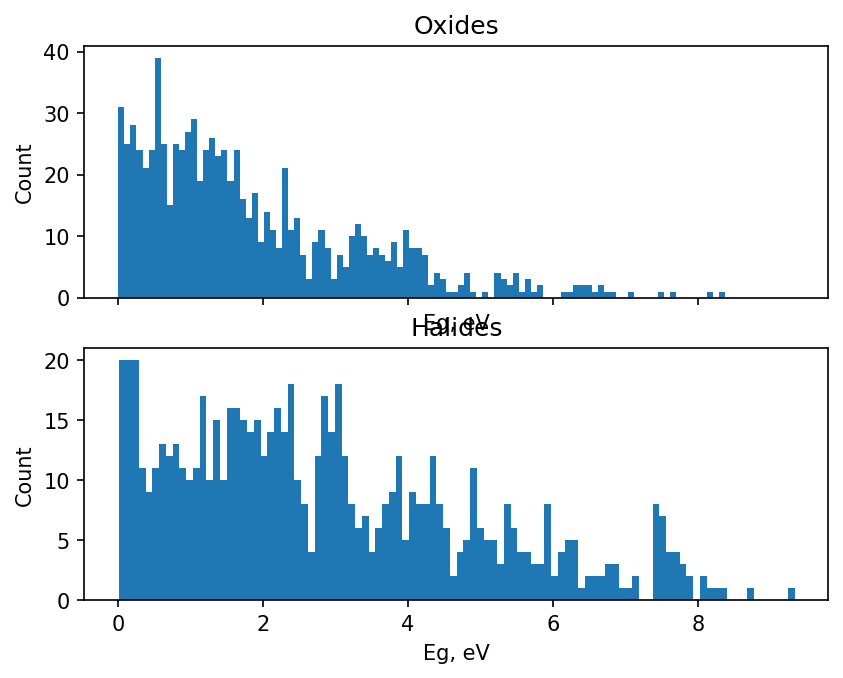

In [38]:
fig, (ax1, ax2) = plt.subplots(dpi = 150, nrows = 2, sharex = True)
_ = ax1.hist(oxides.eg, bins = 100)
_ = ax2.hist(halides.eg, bins = 100)

ax1.set_title('Oxides')
ax1.set_xlabel('Eg, eV')
ax1.set_ylabel('Count')

ax2.set_title('Halides')
ax2.set_xlabel('Eg, eV')
ax2.set_ylabel('Count')



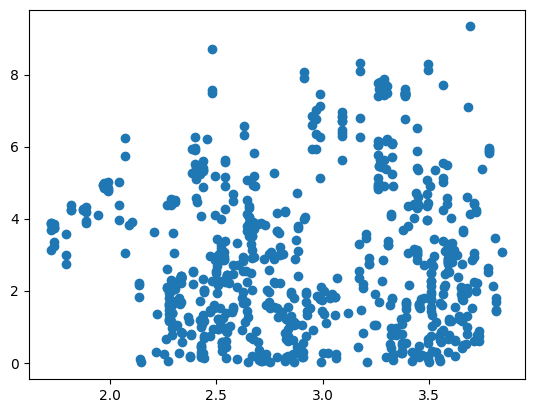

In [39]:
#plt.scatter(oxides.elneg_mean, oxides.eg)
plt.scatter(halides.elneg_mean, halides.eg)

In [40]:
group = halides.drop(columns = ['chemsys', 'formula']).groupby(by = 'family').mean().reset_index()

In [41]:
group = group[group.family != 'phosphide']
group = group[group.family != 'sulfide']
group = group[group.family != 'oxide']

,family,eg,nelements,elneg_mean,has_halogen,electrons_per_atom
0,bromide,2.258347,2.0,2.483990,1.0,37.763241
1,chloride,2.515402,2.0,2.676061,1.0,25.514685
2,fluoride,3.535337,2.0,3.402445,1.0,16.474479
3,iodide,2.129898,2.0,2.279406,1.0,49.876991


Text(0.5, 0, '<mean elneg>, eV')

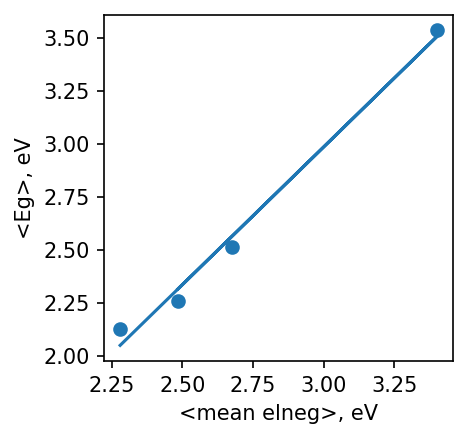

In [50]:
plt.figure(dpi = 150, figsize = (3, 3))
plt.scatter(group.elneg_mean, group.eg)
res = linregress(group.elneg_mean, group.eg)
plt.plot(group.elneg_mean, group.elneg_mean * res.slope + res.intercept)

plt.ylabel('<Eg>, eV')
plt.xlabel('<mean elneg>, eV')


#### Task 2

In [51]:
# download files
!mkdir data
!wget -O./data/LiIonDatabase_poisoned.csv https://raw.githubusercontent.com/dembart/intro-to-materials-informatics/refs/heads/main/data/seminar04/LiIonDatabase_poisoned.csv

mkdir: cannot create directory ‘data’: File exists
--2026-10-05 12:04:46--  https://raw.githubusercontent.com/dembart/intro-to-materials-informatics/refs/heads/main/data/seminar04/LiIonDatabase_poisoned.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 65926 (64K) [text/plain]
Saving to: ‘./data/LiIonDatabase_poisoned.csv’

./data/LiIonDatabas 100%[===================>]  64.38K  --.-KB/s    in 0.05s   

2026-10-05 12:04:47 (1.36 MB/s) - ‘./data/LiIonDatabase_poisoned.csv’ saved [65926/65926]



In [52]:
# read data

df = pd.read_csv('data/LiIonDatabase_poisoned.csv')

In [53]:

df = df.drop(columns = ['0', 'source', 'ID'])

In [54]:
#df[df.isna() == False]
df = df.dropna()


In [55]:
df = df[df.target > 0]
df = df[df.temperature < 30]
df

,composition,temperature,target,family,ChemicalFamily
1,Li2OHBr,22.06,5.400000e-07,Anti-Perovskite,Oxides and Other Anions
2,Li2.4OH0.6Cl,26.00,1.200000e+01,Anti-Perovskite,Oxides and Other Anions
3,Li2.1OH0.9Cl,26.00,8.050000e-08,Anti-Perovskite,Oxides and Other Anions
4,Li2OHCl,26.00,7.110000e-08,Anti-Perovskite,Oxides and Other Anions
5,Li2.7OH0.3Cl,26.00,7.300000e-09,Anti-Perovskite,Oxides and Other Anions
...,...,...,...,...,...
815,Li3.6Ge0.4P0.6S4,25.00,2.213560e-04,Thio-LISICON,Sulphides
816,Li3.35Ge0.35P0.65S4,25.00,1.830655e-03,Thio-LISICON,Sulphides
817,Li6NiCl8,25.00,2.690000e-10,Rocksalt,Halides
818,Li6CoCl8,25.00,1.510000e-06,Rocksalt,Halides


array([[<Axes: title={'center': 'target'}>]], dtype=object)

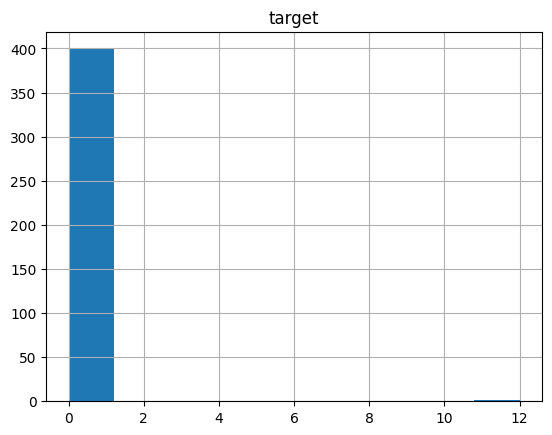

In [56]:
df[['target']].hist()

In [57]:
df = df[df.target <= df.quantile(q=0.99, numeric_only=True)['target']]


In [58]:
import numpy as np

df['log_target'] = np.log(df.target)
df_mean = df.drop(columns = ['composition', 'ChemicalFamily']).groupby(by = 'family').mean().reset_index()
df_mean = df_mean.sort_values(by = 'log_target')
df_std = df.drop(columns = ['composition', 'ChemicalFamily']).groupby(by = 'family').std().reset_index()
df_std['log_target_std'] = df_std['log_target']
data = df_mean.merge(df_std[['family', 'log_target_std']])
data


/tmp/ipykernel_1516/2800272738.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['log_target'] = np.log(df.target)


,family,temperature,target,log_target,log_target_std
0,Phenakite,25.000000,2.193333e-11,-24.635510,0.553191
1,Lysonite,25.000000,2.971750e-10,-23.603260,3.324342
2,Olivine,25.000000,6.578620e-10,-22.197531,2.249179
3,Rocksalt,25.000000,1.946746e-06,-17.936433,6.511666
4,LISICON,25.000000,6.092892e-06,-17.047133,5.887886
5,Zircon,25.000000,3.642659e-06,-17.005697,5.309145
6,Anti-Perovskite,25.778333,1.566265e-04,-14.448380,4.058545
7,Other,25.117647,2.243214e-04,-13.074051,7.022029
8,Glass,25.035185,5.509786e-04,-12.638151,5.051019
9,Glass-Ceramic,19.000000,8.176222e-05,-12.193866,3.790221


In [59]:
df_mean

,family,temperature,target,log_target
11,Phenakite,25.000000,2.193333e-11,-24.635510
6,Lysonite,25.000000,2.971750e-10,-23.603260
8,Olivine,25.000000,6.578620e-10,-22.197531
12,Rocksalt,25.000000,1.946746e-06,-17.936433
5,LISICON,25.000000,6.092892e-06,-17.047133
14,Zircon,25.000000,3.642659e-06,-17.005697
0,Anti-Perovskite,25.778333,1.566265e-04,-14.448380
9,Other,25.117647,2.243214e-04,-13.074051
3,Glass,25.035185,5.509786e-04,-12.638151
4,Glass-Ceramic,19.000000,8.176222e-05,-12.193866


<ErrorbarContainer object of 3 artists>

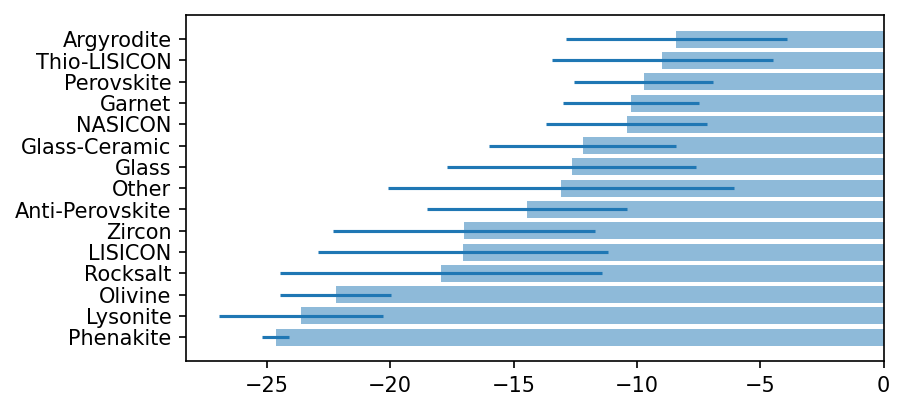

In [60]:
plt.figure(dpi = 150, figsize = (6, 3))

plt.barh(df_mean.family, df_mean.log_target, alpha = 0.5)
plt.errorbar(data.log_target, data.family, xerr = data.log_target_std, linestyle = '')
